# Vectorización: TF-IDF y N-gramas

---

## Objetivo

En el cuaderno anterior vimos que Bag of Words trata todas las palabras como igualmente importantes. Si "el" aparece diez veces en un texto, suma diez al vector, igual que "inflación" o "messi". Eso es un problema: las palabras muy frecuentes en todo el corpus dominan los conteos y ocultan los términos que realmente definen el contenido de cada documento.

En este cuaderno vamos a ver dos técnicas que corrigen ese problema:

- **TF-IDF**: pondera la importancia de cada palabra según qué tan *rara* es en el corpus.
- **N-gramas**: captura secuencias de palabras contiguas para preservar términos compuestos.

## Resultados de aprendizaje

Al finalizar este cuaderno vas a poder:

- Diferenciar entre la frecuencia simple de términos (BoW) y su importancia relativa (TF-IDF).
- Implementar y comparar BoW y TF-IDF usando `scikit-learn`.
- Interpretar una matriz TF-IDF e identificar los términos más relevantes por documento.
- Aplicar N-gramas para capturar términos compuestos como "Buenos Aires" o "Lionel Messi".
- Visualizar comparativamente los pesos de BoW y TF-IDF en un gráfico de barras.

## Relación con cuadernos anteriores

- En `001_bag_of_words` construiste matrices de conteo con `CountVectorizer`.
- **Acá** vas a incorporar `TfidfVectorizer` para ponderar esos conteos, y `ngram_range` para capturar secuencias de palabras.

---

## Sección 0: Preparación del entorno

Vamos a trabajar con un corpus nuevo: descripciones breves de ciudades argentinas. Lo elegimos porque:

- Las palabras clave son reconocibles ("viñedos", "universitaria", "Andes").
- Tiene términos compuestos reales ("Buenos Aires", "Che Guevara", "Lionel Messi") que vamos a explotar en la sección de N-gramas.
- La palabra "es" aparece en todas las oraciones, lo que nos va a permitir ver con claridad la diferencia entre BoW y TF-IDF.

A continuación importamos las librerías necesarias y definimos el corpus.

In [1]:
# --- Importaciones ---

# CountVectorizer: cuenta frecuencias (BoW), ya lo usamos en el cuaderno anterior.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# pandas: muestra los resultados en tablas legibles.
import pandas as pd

# matplotlib y seaborn: para gráficos comparativos.
import matplotlib.pyplot as plt
import seaborn as sns

# --- Corpus: descripciones de ciudades argentinas ---
corpus_ciudades = [
    "Buenos Aires es la capital y ciudad más poblada de Argentina",
    "Córdoba es la segunda ciudad más grande y tiene tradición universitaria",
    "Rosario es la ciudad natal de Ernesto Che Guevara y Lionel Messi",
    "Mendoza es famosa por sus viñedos y por estar cerca de los Andes",
]

# Etiquetas para identificar cada documento en las tablas
etiquetas_ciudades = ["Buenos Aires", "Córdoba", "Rosario", "Mendoza"]

print("Corpus de trabajo:")
for etiqueta, texto in zip(etiquetas_ciudades, corpus_ciudades):
    print(f"  [{etiqueta}] {texto}")

Corpus de trabajo:
  [Buenos Aires] Buenos Aires es la capital y ciudad más poblada de Argentina
  [Córdoba] Córdoba es la segunda ciudad más grande y tiene tradición universitaria
  [Rosario] Rosario es la ciudad natal de Ernesto Che Guevara y Lionel Messi
  [Mendoza] Mendoza es famosa por sus viñedos y por estar cerca de los Andes


Observá que la palabra **"es"** aparece en los cuatro documentos. En BoW va a acumular una frecuencia alta en cada fila, aunque no aporte nada para distinguir a qué ciudad refiere cada texto. Vamos a ver cómo TF-IDF maneja ese problema.

---

## Sección 1: Bag of Words — El problema de las palabras frecuentes

Como ya vimos, BoW cuenta cuántas veces aparece cada palabra en cada documento sin distinguir si esa palabra es relevante o no para el texto.

Antes de ejecutar el código, reflexioná:

- ¿Qué palabras creés que van a dominar la matriz?
- ¿"ciudad" o "es" ayudan a distinguir Buenos Aires de Córdoba de Rosario?

In [2]:
# --- Implementación de Bag of Words ---

# Inicializamos el contador de frecuencias
contador_bow = CountVectorizer()

# Aprendemos el vocabulario y construimos la matriz de conteos
matriz_bow    = contador_bow.fit_transform(corpus_ciudades)
vocabulario   = contador_bow.get_feature_names_out()

# Visualizamos la matriz en una tabla
tabla_bow = pd.DataFrame(
    matriz_bow.toarray(),
    columns=vocabulario,
    index=etiquetas_ciudades
)

print("Matriz de frecuencias (Bag of Words):")
tabla_bow

Matriz de frecuencias (Bag of Words):


,aires,andes,argentina,buenos,capital,cerca,che,ciudad,córdoba,de,...,natal,poblada,por,rosario,segunda,sus,tiene,tradición,universitaria,viñedos
Buenos Aires,1,0,1,1,1,0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
Córdoba,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,1,0,1,1,1,0
Rosario,0,0,0,0,0,0,1,1,0,1,...,1,0,0,1,0,0,0,0,0,0
Mendoza,0,1,0,0,0,1,0,0,0,1,...,0,0,2,0,0,1,0,0,0,1


### ¿Qué observamos?

Mirá las columnas "ciudad" y "es". Tienen valores similares en múltiples filas, pero no dicen nada útil sobre qué distingue a cada ciudad.

Ahora fijate en "viñedos" (Mendoza), "Messi" (Rosario) o "universitaria" (Córdoba). Esas sí son palabras *diagnósticas*: aparecen solo en un documento.

**El problema de BoW**: trata igual a "es" y a "Messi". Ambas suman 1 al vector, aunque "Messi" aporte mucho más información.

> **Para reflexionar**: si estuvieras clasificando estos textos a mano, ¿a qué palabras les darías más peso? ¿Cómo replicarías eso en código?

---

## Sección 2: TF-IDF — Ponderando la importancia

**TF-IDF** (Term Frequency – Inverse Document Frequency) resuelve el problema asignando un peso que combina dos ideas:

- **TF (Frecuencia del término)**: cuántas veces aparece la palabra en *ese* documento. Igual que BoW.
- **IDF (Frecuencia inversa de documento)**: qué tan *rara* es la palabra en *todo* el corpus. Si aparece en muchos documentos, su IDF baja. Si aparece en pocos, su IDF sube.

El peso final es: **TF × IDF**

Así, "es" —que aparece en los cuatro documentos— recibe un IDF bajo y su peso final queda cerca de cero. "Messi" —exclusiva de un solo documento— recibe un IDF alto y domina el vector de Rosario.

### ¿Por qué importa eso?

Porque el vector resultante ya no describe "cuántas palabras tiene el texto" sino "qué palabras hacen a este texto *diferente* de los demás".

In [3]:
# --- Implementación de TF-IDF ---

# Inicializamos el vectorizador TF-IDF
vectorizador_tfidf = TfidfVectorizer()

# Aprendemos y transformamos el corpus
matriz_tfidf      = vectorizador_tfidf.fit_transform(corpus_ciudades)
vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()

# Visualizamos los pesos resultantes
tabla_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=vocabulario_tfidf,
    index=etiquetas_ciudades
)

print("Matriz de pesos TF-IDF (redondeados a 3 decimales):")
tabla_tfidf.round(3)

Matriz de pesos TF-IDF (redondeados a 3 decimales):


,aires,andes,argentina,buenos,capital,cerca,che,ciudad,córdoba,de,...,natal,poblada,por,rosario,segunda,sus,tiene,tradición,universitaria,viñedos
Buenos Aires,0.375,0.000,0.375,0.375,0.375,0.000,0.000,0.239,0.00,0.239,...,0.000,0.375,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.000
Córdoba,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.230,0.36,0.000,...,0.000,0.000,0.000,0.000,0.36,0.000,0.36,0.36,0.36,0.000
Rosario,0.000,0.000,0.000,0.000,0.000,0.000,0.343,0.219,0.00,0.219,...,0.343,0.000,0.000,0.343,0.00,0.000,0.00,0.00,0.00,0.000
Mendoza,0.000,0.281,0.000,0.000,0.000,0.281,0.000,0.000,0.00,0.179,...,0.000,0.000,0.562,0.000,0.00,0.281,0.00,0.00,0.00,0.281


Compará con la tabla de BoW. Vas a notar que:

- **"es"** ahora tiene un peso cercano a cero en todos los documentos: como aparece en los cuatro, su IDF es muy bajo.
- **"viñedos"** tiene un peso alto exclusivamente en la fila de Mendoza: es rara en el corpus (aparece solo ahí), por eso su IDF sube.
- **"messi"** domina el vector de Rosario por el mismo motivo.
- **"ciudad"** tiene un peso intermedio: aparece en tres documentos (no en todos), así que su IDF no es tan bajo como el de "es".

---

## Sección 3: Comparativa visual

Vamos a graficar los valores de BoW y TF-IDF para un mismo documento y ver la diferencia de forma intuitiva. Elegimos Rosario porque tiene los términos más reconocibles: "Messi", "Guevara", "natal".

El gráfico va a mostrar dos barras por término: la de la izquierda (BoW) y la de la derecha (TF-IDF). Las diferencias de altura muestran exactamente cómo TF-IDF redistribuye la importancia.

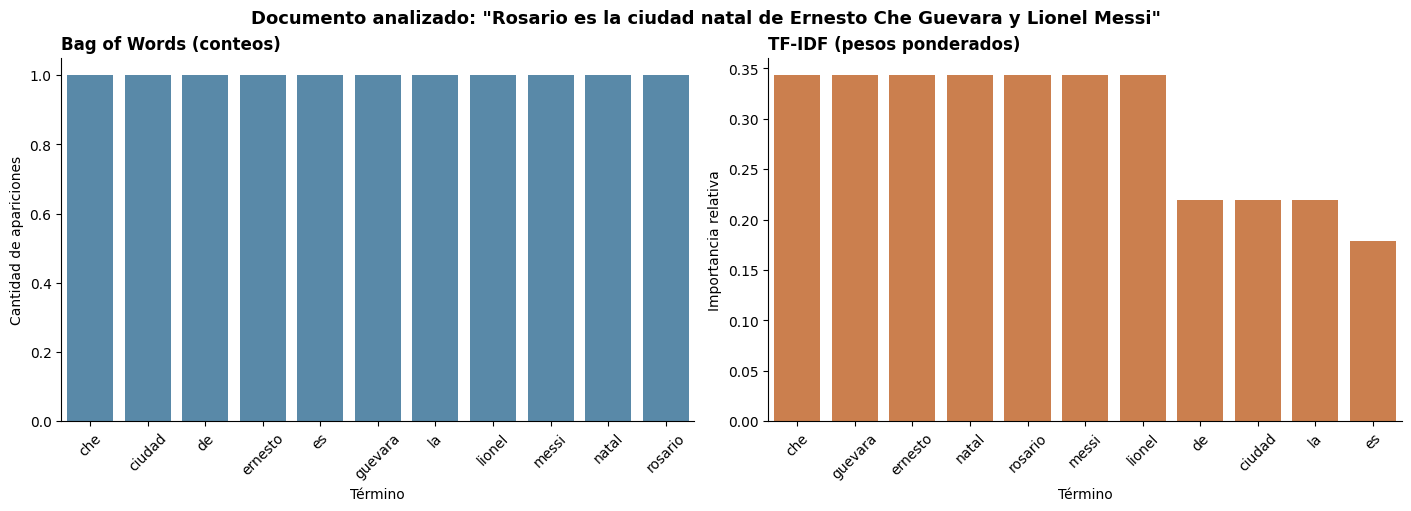

In [4]:
# --- Comparativa visual: BoW vs TF-IDF para el documento de Rosario ---

# Elegimos el índice 2 (Rosario, "Ernesto Che Guevara y Lionel Messi")
indice_doc = 2

# Preparamos los datos de BoW para ese documento
datos_bow = pd.DataFrame({
    "palabra": vocabulario,
    "valor":   matriz_bow[indice_doc].toarray()[0],
    "método":  "BoW",
})

# Preparamos los datos de TF-IDF para el mismo documento
datos_tfidf = pd.DataFrame({
    "palabra": vocabulario_tfidf,
    "valor":   matriz_tfidf[indice_doc].toarray()[0],
    "método":  "TF-IDF",
})

# Creamos el gráfico con dos paneles: uno por método
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel izquierdo: BoW
sns.barplot(
    data=datos_bow[datos_bow["valor"] > 0].sort_values("valor", ascending=False),
    x="palabra", y="valor", ax=ax1, color="#4C8CB5"
)
ax1.set_title("Bag of Words (conteos)", fontweight="bold", loc="left")
ax1.set_xlabel("Término")
ax1.set_ylabel("Cantidad de apariciones")
ax1.tick_params(axis="x", rotation=45)
sns.despine(ax=ax1)

# Panel derecho: TF-IDF
sns.barplot(
    data=datos_tfidf[datos_tfidf["valor"] > 0].sort_values("valor", ascending=False),
    x="palabra", y="valor", ax=ax2, color="#E07B39"
)
ax2.set_title("TF-IDF (pesos ponderados)", fontweight="bold", loc="left")
ax2.set_xlabel("Término")
ax2.set_ylabel("Importancia relativa")
ax2.tick_params(axis="x", rotation=45)
sns.despine(ax=ax2)

titulo = corpus_ciudades[indice_doc]
fig.suptitle(f'Documento analizado: "{titulo}"', fontsize=13, fontweight="bold")
plt.show()


### ¿Qué muestra el gráfico?

- En **BoW** (izquierda), todas las palabras del documento valen 1: "es", "ciudad", "messi" y "guevara" aparecen a la misma altura.
- En **TF-IDF** (derecha), "messi", "guevara" y "natal" escalan hacia arriba, mientras que "es" y "ciudad" caen al fondo.

Esto es exactamente lo que queríamos: TF-IDF pone en primer plano los términos que definen a *este* documento dentro del corpus, y relega el "ruido frecuente".

---

## Sección 4: N-gramas — Más allá de palabras sueltas

Hasta ahora tratamos cada palabra de forma individual (*unigramas*). Eso genera un problema: "Buenos Aires" se parte en "buenos" y "aires", dos palabras sueltas sin el significado del conjunto.

Los **N-gramas** son secuencias contiguas de palabras:

- **Unigramas (N=1)**: palabra a palabra — el comportamiento por defecto de BoW.
- **Bigramas (N=2)**: pares de palabras — "Buenos Aires", "Lionel Messi".
- **Trigramas (N=3)**: tríos de palabras — "Ernesto Che Guevara".

Vamos a ver primero el problema con unigramas y luego la solución con N-gramas.

In [5]:
# --- El problema con unigramas: "Buenos Aires" se rompe ---

contador_unigrama = CountVectorizer(ngram_range=(1, 1))  # comportamiento por defecto
contador_unigrama.fit_transform(corpus_ciudades)
vocab_unigrama = contador_unigrama.get_feature_names_out()

# Buscamos "buenos" y "aires" por separado
terminos_busqueda = ["buenos", "aires", "lionel", "messi", "ernesto", "guevara"]
encontrados = []
for termino in terminos_busqueda:
    if termino in vocab_unigrama:
        encontrados.append(termino)


print("Con unigramas, el vocabulario contiene estas palabras sueltas:")
print(encontrados)
print()
print("-> 'Buenos Aires' se convirtió en 'buenos' y 'aires' por separado.")
print("-> 'Lionel Messi' se convirtió en 'lionel' y 'messi' por separado.")
print("-> 'Ernesto Che Guevara' se convirtió en tres palabras sin relación.")

Con unigramas, el vocabulario contiene estas palabras sueltas:
['buenos', 'aires', 'lionel', 'messi', 'ernesto', 'guevara']

-> 'Buenos Aires' se convirtió en 'buenos' y 'aires' por separado.
-> 'Lionel Messi' se convirtió en 'lionel' y 'messi' por separado.
-> 'Ernesto Che Guevara' se convirtió en tres palabras sin relación.


Este es el problema: si alguien busca "Lionel Messi" en un sistema que usa unigramas, el modelo no sabe que "lionel" y "messi" forman una unidad. "Lionel" podría aparecer en documentos sobre otras personas llamadas Lionel, y "messi" podría ser confundido con el adjetivo inglés *messy*.

Los N-gramas resuelven esto: con bigramas, "lionel messi" se convierte en un solo token que el modelo trata como unidad.

In [6]:
# --- La solución: N-gramas (unigramas + bigramas + trigramas) ---

# ngram_range=(1, 3) le dice al contador que capture secuencias
# de 1, 2 y 3 palabras contiguas.
contador_ngramas = CountVectorizer(ngram_range=(1, 3))
matriz_ngramas   = contador_ngramas.fit_transform(corpus_ciudades)
vocab_ngramas    = contador_ngramas.get_feature_names_out()

# Buscamos los términos compuestos que nos interesan
frases_clave = [
    "buenos aires", "lionel messi", "ernesto che guevara",
    "che guevara", "tradición universitaria", "ciudad natal"
]

encontrados_ngramas = []
for frase in frases_clave:
    if frase in vocab_ngramas:
        encontrados_ngramas.append(frase)


print(f"Vocabulario total con N-gramas (1 a 3): {len(vocab_ngramas)} términos.")
print()
print("Términos compuestos capturados:")
for frase in encontrados_ngramas:
    print(f"  ✓ '{frase}'")

# Mostramos los conteos de esas frases para el corpus completo
tabla_ngramas = pd.DataFrame(
    matriz_ngramas.toarray(),
    columns=vocab_ngramas,
    index=etiquetas_ciudades
)
print()
print("Conteos de frases clave en el corpus:")
tabla_ngramas[encontrados_ngramas]

Vocabulario total con N-gramas (1 a 3): 103 términos.

Términos compuestos capturados:
  ✓ 'buenos aires'
  ✓ 'lionel messi'
  ✓ 'ernesto che guevara'
  ✓ 'che guevara'
  ✓ 'tradición universitaria'
  ✓ 'ciudad natal'

Conteos de frases clave en el corpus:


,buenos aires,lionel messi,ernesto che guevara,che guevara,tradición universitaria,ciudad natal
Buenos Aires,1,0,0,0,0,0
Córdoba,0,0,0,0,1,0
Rosario,0,1,1,1,0,1
Mendoza,0,0,0,0,0,0


### ¿Qué ganamos con N-gramas?

- **"buenos aires"** aparece como una unidad en la fila de Buenos Aires. El modelo ahora sabe que es una entidad con sentido propio.
- **"lionel messi"** y **"ernesto che guevara"** quedan capturados en la fila de Rosario, vinculando ambas palabras correctamente.
- **"ciudad natal"** es un bigrama que describe la relación de Rosario con sus figuras históricas.

> **Ojo con el tamaño del vocabulario**: fijate que con N-gramas (1,3) el vocabulario explotó. Con textos reales de miles de palabras, esto puede generar matrices enormes. Hay que calibrar `ngram_range` según el caso de uso.

---

## Actividad de cierre

Antes de responder, ejecutá el código varias veces cambiando los parámetros.

### Consigna

1. Cambiá `ngram_range=(1, 3)` a `ngram_range=(2, 2)` (solo bigramas). ¿Cuántos términos tiene el vocabulario? ¿Cuáles desaparecen?
2. Volvé al corpus de ciudades y aplicale `TfidfVectorizer` con `ngram_range=(1, 2)`. ¿Qué bigrama tiene el peso más alto para el documento de Mendoza? ¿Por qué?
3. **Para reflexionar**: ¿En qué situaciones creés que conviene usar trigramas? ¿Cuándo serían contraproducentes?

*Pista para la pregunta 3*: pensá en qué pasa cuando una secuencia de tres palabras aparece solo una vez en el corpus. ¿Qué IDF le asignaría TF-IDF?

---

## Cierre — Ideas clave

| Técnica | Qué hace | Cuándo conviene |
|---------|----------|-----------------|
| **BoW** | Cuenta frecuencias sin distinción de importancia | Corpus pequeños, exploración inicial |
| **TF-IDF** | Pondera cada palabra según su rareza en el corpus | Clasificación, búsqueda, ranking |
| **Unigramas** | Tokeniza palabra a palabra | La mayoría de los casos |
| **N-gramas** | Captura secuencias de N palabras contiguas | Entidades nombradas, términos técnicos |

### Glosario

- **Token**: unidad mínima de procesamiento (generalmente una palabra).
- **Corpus**: conjunto de documentos a analizar.
- **Matriz esparsa**: formato eficiente donde solo se guardan los valores distintos de cero.
- **IDF** (*Inverse Document Frequency*): penalización para palabras muy frecuentes en el corpus.
- **N-grama**: secuencia de N palabras contiguas tratadas como una sola unidad.

**En los próximos cuadernos** vamos a ver cómo estas representaciones numéricas se usan como entrada para algoritmos de clasificación, búsqueda y análisis de similitud entre documentos.